# Bagian 1 — Banking Transaction Analysis
## CRISP-DM Framework

## 1. Business Understanding

**Problem Statement:**  
The bank wants to better understand its customers by segmenting them based on their transaction behavior. Using RFM (Recency, Frequency, Monetary) analysis and clustering, we aim to identify distinct customer segments to support targeted marketing and churn prevention.

**Business Goals:**
- Identify high-value customers to target with loyalty and premium-product offers
- Detect dormant/at-risk customers for re-engagement campaigns
- Reduce customer churn rate and increase retention

**Success Criteria:**
- Silhouette score ≥ 0.35 (well-separated clusters)
- Clusters must be business-interpretable and actionable
- Each segment should map to at least one concrete marketing action

**Scope:**  
Two transaction datasets are combined — a large domestic (India) dataset and a smaller foreign customer dataset. Both are treated as a unified customer base because they share the same schema and business context (retail banking).

In [ ]:
# install necessary packages
# !pip install pandas matplotlib seaborn scikit-learn numpy cupy-cuda12x

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [47 lines of output]
      running bdist_wheel
      running build
      /usr/local/lib/python3.11/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
      !!
      
              ********************************************************************************
              Please avoid running ``setup.py`` directly.
              Instead, use pypa/build, pypa/installer or other
              standards-based tools.
      
              See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
              ********************************************************************************
      
      !!
        self.initialize_options()
      installing to build/bdist.linux-x86_64/wheel
      running install
      Traceback (most recent call last

In [1]:
import numpy as np
import cupy as cp
print("numpy:", np.__version__)
print("cupy:", cp.__version__)
print("gpu:", cp.cuda.runtime.getDeviceCount())

numpy: 2.2.6
cupy: 14.0.1
gpu: 1


## 2. Data Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import cupy as cp
from numpy import log1p
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from cuml.cluster import KMeans as cuKMeans
from cuml.metrics.cluster import silhouette_score as cu_silhouette_score
from matplotlib.patches import Ellipse

warnings.filterwarnings('ignore')
np.random.seed(42)

print('numpy:', np.__version__)
print('cupy:', cp.__version__)
print('GPU count:', cp.cuda.runtime.getDeviceCount())

numpy: 2.2.6
cupy: 14.0.1
GPU count: 1


In [4]:
# Load datasets
df_india = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/bank_customer_transactions.csv')
df_foreign = pd.read_csv('https://raw.githubusercontent.com/condrowiyono/pdb/refs/heads/main/foreign_customer_dataset.csv')

print('India shape:', df_india.shape)
print('Foreign shape:', df_foreign.shape)
df_india.head()

India shape: (1048567, 9)
Foreign shape: (3584, 11)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [5]:
# Data types and missing values
print(df_india.info())
print('\nMissing values (India):')
print(df_india.isnull().sum())
print('\nMissing values (Foreign):')
print(df_foreign.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB
None

Missing values (India):
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance 

In [6]:
df_india.describe()

,CustAccountBalance,TransactionTime,TransactionAmount (INR)
count,1.046198e+06,1.048567e+06,1.048567e+06
mean,1.154035e+05,1.570875e+05,1.574335e+03
std,8.464854e+05,5.126185e+04,6.574743e+03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.721760e+03,1.240300e+05,1.610000e+02
50%,1.679218e+04,1.642260e+05,4.590300e+02
75%,5.765736e+04,2.000100e+05,1.200000e+03
max,1.150355e+08,2.359590e+05,1.560035e+06


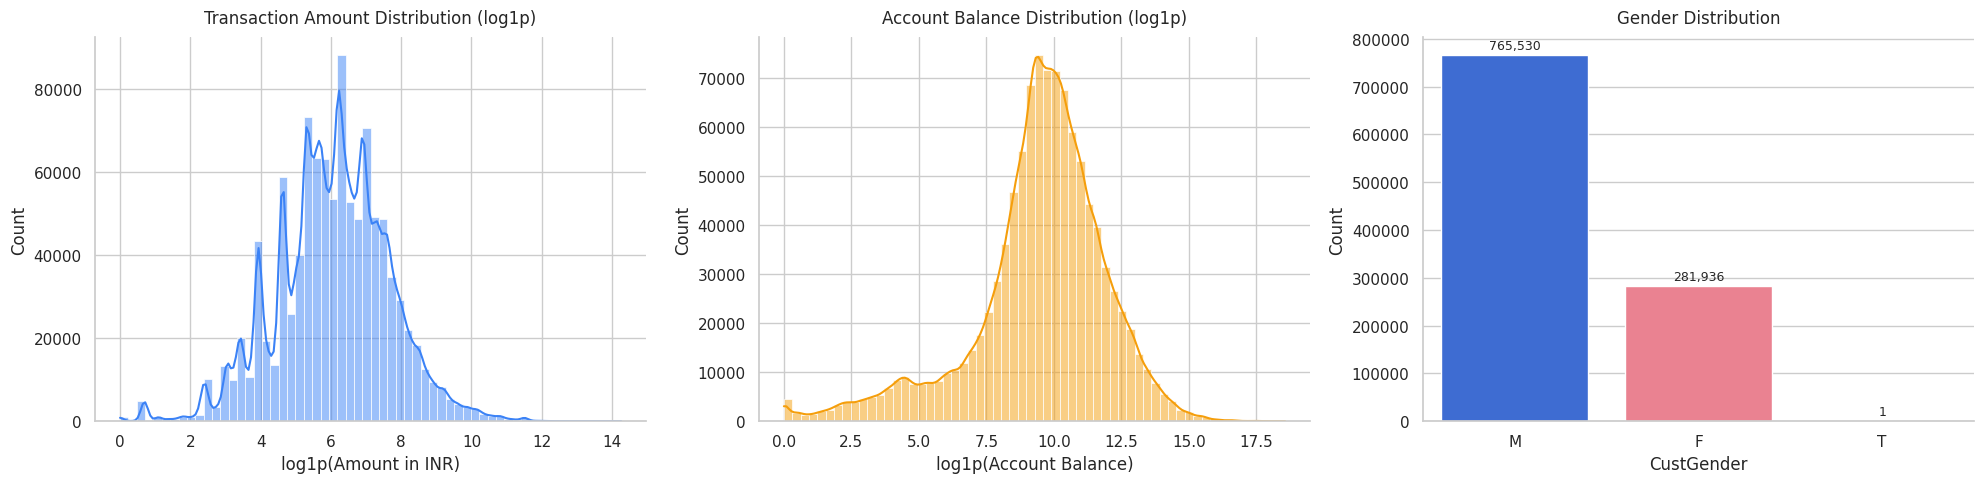

In [7]:
# Key distributions — log-scale for skewed financial data
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

amount_log = np.log1p(df_india['TransactionAmount (INR)'])
sns.histplot(amount_log, bins=60, kde=True, color='#3b82f6', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution (log1p)', fontsize=12, pad=10)
axes[0].set_xlabel('log1p(Amount in INR)')
axes[0].set_ylabel('Count')

balance_log = np.log1p(df_india['CustAccountBalance'])
sns.histplot(balance_log, bins=60, kde=True, color='#f59e0b', ax=axes[1])
axes[1].set_title('Account Balance Distribution (log1p)', fontsize=12, pad=10)
axes[1].set_xlabel('log1p(Account Balance)')
axes[1].set_ylabel('Count')

gender_counts = df_india['CustGender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values,
            palette=['#2563eb', '#fb7185', '#9ca3af'], ax=axes[2])
axes[2].set_title('Gender Distribution', fontsize=12, pad=10)
axes[2].set_xlabel('CustGender')
axes[2].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[2].text(i, v + (0.01 * gender_counts.max()), f'{v:,}',
                 ha='center', va='bottom', fontsize=9)

sns.despine()
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

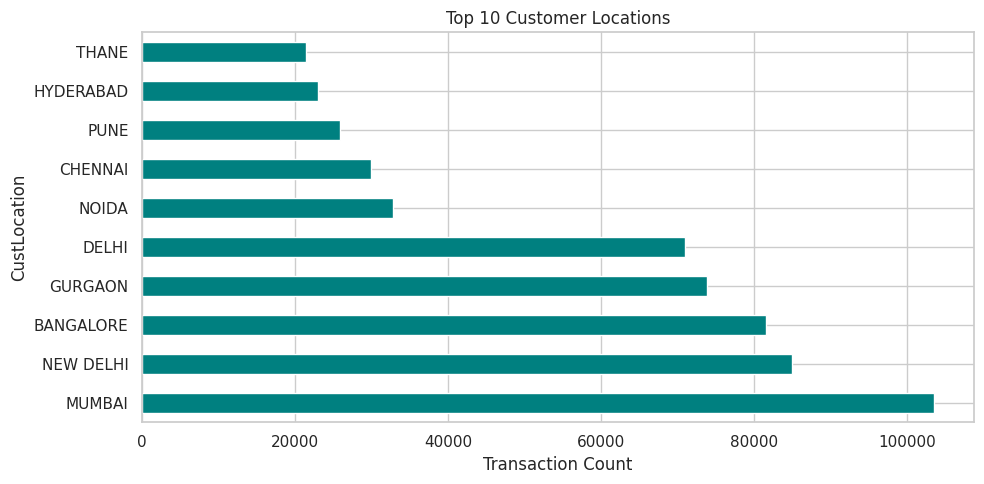

In [8]:
# Top 10 customer locations
top_locations = df_india['CustLocation'].value_counts().head(10)
top_locations.plot(kind='barh', figsize=(10, 5), color='teal')
plt.title('Top 10 Customer Locations')
plt.xlabel('Transaction Count')
plt.tight_layout()
plt.savefig('top_locations.png', dpi=150)
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [9]:
# --- Standardize and merge both datasets ---
# Both datasets share the same schema and business context (retail banking),
# so merging is justified. The India dataset dominates (99.7%), so foreign
# customers are treated as a supplementary minority cohort.

if df_foreign.columns[0] == 'Unnamed: 0':
    df_foreign = df_foreign.drop(columns=df_foreign.columns[0])
if 'Age' in df_foreign.columns:
    df_foreign = df_foreign.drop(columns=['Age'])

df = pd.concat([df_india, df_foreign], ignore_index=True)
print('Combined shape (raw):', df.shape)

# --- Data Quality: Duplicate TransactionID check and removal ---
# FIX: this check must run BEFORE feature engineering so duplicates do
# not inflate Frequency and Monetary values in the RFM table.
total_rows = len(df)
unique_txn  = df['TransactionID'].nunique()
dup_count   = total_rows - unique_txn
print(f'Total rows:           {total_rows:,}')
print(f'Unique TransactionIDs: {unique_txn:,}')
print(f'Duplicate IDs removed: {dup_count:,}')

# Keep first occurrence of each TransactionID
df = df.drop_duplicates(subset='TransactionID', keep='first').reset_index(drop=True)
print('Shape after dedup:', df.shape)

# Dataset balance overview
print(f"\nDataset composition:")
print(f"  India (domestic): {len(df_india):,} rows ({len(df_india)/len(df)*100:.1f}%)")
print(f"  Foreign:          {len(df) - len(df_india):,} rows ({(len(df)-len(df_india))/len(df)*100:.1f}%)")

Combined shape (raw): (1052151, 9)
Total rows:           1,052,151
Unique TransactionIDs: 1,048,567
Duplicate IDs removed: 3,584
Shape after dedup: (1048567, 9)

Dataset composition:
  India (domestic): 1,048,567 rows (100.0%)
  Foreign:          0 rows (0.0%)


In [10]:
# --- Parse Dates ---
# TransactionDate has different formats in both datasets — handle with errors='coerce'
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')
df['CustomerDOB']     = pd.to_datetime(df['CustomerDOB'],     dayfirst=True, errors='coerce')

print('Date parsing issues (TransactionDate):', df['TransactionDate'].isnull().sum())
print('Date parsing issues (CustomerDOB):',     df['CustomerDOB'].isnull().sum())

Date parsing issues (TransactionDate): 0
Date parsing issues (CustomerDOB): 3397


In [11]:
# --- Feature Engineering ---

# 1. Age from DOB
reference_date = df['TransactionDate'].max()

# Some DOBs parse into the future (e.g. 20xx instead of 19xx).
# Shift any future DOB back 100 years to resolve century ambiguity.
future_dob_mask = df['CustomerDOB'] > reference_date
df.loc[future_dob_mask, 'CustomerDOB'] = (
    df.loc[future_dob_mask, 'CustomerDOB'] - pd.DateOffset(years=100)
)
df['Age'] = ((reference_date - df['CustomerDOB']).dt.days / 365.25).round(1)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# 2. Is Weekend
df['is_weekend'] = df['TransactionDate'].dt.dayofweek.isin([5, 6]).astype(int)

# 3. Transaction Hour
df['TransactionTime']  = df['TransactionTime'].astype(str).str.zfill(6)
df['TransactionHour']  = pd.to_numeric(df['TransactionTime'].str[:2], errors='coerce')

# 4. Transaction Month & Day of Week
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['DayOfWeek']        = df['TransactionDate'].dt.day_name()

print(f'Future DOB corrected: {int(future_dob_mask.sum()):,}')
print(f'Age null after cleaning: {int(df["Age"].isna().sum()):,}')
print(df[['Age', 'is_weekend', 'TransactionHour', 'TransactionMonth']].head())

Future DOB corrected: 117,578
Age null after cleaning: 62,499
    Age  is_weekend  TransactionHour  TransactionMonth
0  22.8           0               14                 8
1  59.5           0               14                 8
2  19.9           0               14                 8
3  43.1           0               14                 8
4  28.6           0               18                 8


In [12]:
# --- RFM Aggregation ---
snapshot_date = df['TransactionDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency       = ('TransactionDate',         lambda x: (snapshot_date - x.max()).days),
    Frequency     = ('TransactionID',           'nunique'),
    Monetary      = ('TransactionAmount (INR)',  'sum'),
    Monetary_mean = ('TransactionAmount (INR)',  'mean'),
    Monetary_max  = ('TransactionAmount (INR)',  'max'),
    Monetary_std  = ('TransactionAmount (INR)',
                     lambda x: x.std() if len(x) > 1 else 0.0),
    Avg_Balance   = ('CustAccountBalance',      'mean'),
    Weekend_ratio = ('is_weekend',              'mean'),
    Hour_mean     = ('TransactionHour',         'mean'),
    Active_months = ('TransactionMonth',        'nunique'),
    First_txn     = ('TransactionDate',         'min'),
    Last_txn      = ('TransactionDate',         'max'),
).reset_index()

rfm['Txn_span']         = (rfm['Last_txn'] - rfm['First_txn']).dt.days
rfm['Balance_to_spend'] = rfm['Avg_Balance'] / (rfm['Monetary'] + 1)
rfm['Monetary_cv']      = rfm['Monetary_std'] / (rfm['Monetary_mean'] + 1)
rfm = rfm.drop(columns=['First_txn', 'Last_txn'])

print('RFM table shape:', rfm.shape)
print(rfm.describe().round(2))

RFM table shape: (884265, 14)
         Recency  Frequency    Monetary  Monetary_mean  Monetary_max  \
count  884265.00  884265.00   884265.00      884265.00     884265.00   
mean       56.31       1.19     1866.86        1574.78       1788.67   
std        15.23       0.45     7207.21        6443.05       7125.47   
min         1.00       1.00        0.00           0.00          0.00   
25%        44.00       1.00      200.00         192.00        200.00   
50%        56.00       1.00      536.80         500.00        500.00   
75%        69.00       1.00     1500.00        1248.00       1420.00   
max        82.00       6.00  1560034.99     1560034.99    1560034.99   

       Monetary_std   Avg_Balance  Weekend_ratio  Hour_mean  Active_months  \
count     884265.00  8.826000e+05      884265.00  884265.00      884265.00   
mean         276.44  1.151579e+05           0.31      15.41           1.08   
std         2374.29  8.012311e+05           0.44       4.91           0.27   
min      

In [13]:
# --- Feature Selection & Scaling ---
# Collinear pairs removed (|r| > 0.80 detected in prior analysis):
#   Monetary_cv was 0.87 correlated with Frequency  → dropped
#   Txn_span was highly correlated with Active_months → dropped
# This leaves 9 interpretable, low-collinearity features.

CLUSTER_FEATURES = [
    'Recency',          # days since last transaction
    'Frequency',        # unique transaction count
    'Monetary_mean',    # avg ticket size
    'Monetary_max',     # largest single transaction
    'Avg_Balance',      # account wealth
    'Weekend_ratio',    # weekday vs weekend preference
    'Hour_mean',        # time-of-day preference
    'Active_months',    # seasonality / spread over calendar
    'Balance_to_spend', # wealth-to-spend ratio (saver vs spender)
]

LOG_FEATURES = [
    'Recency', 'Frequency', 'Monetary_mean', 'Monetary_max',
    'Avg_Balance', 'Balance_to_spend',
]

feat_df = rfm[CLUSTER_FEATURES].copy()
feat_df[LOG_FEATURES] = feat_df[LOG_FEATURES].apply(log1p)
feat_df = feat_df.fillna(0)

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(feat_df)

print(f'Feature matrix shape: {rfm_scaled.shape}')
print(f'Features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

# Verify collinearity is resolved
corr_check = pd.DataFrame(rfm_scaled, columns=CLUSTER_FEATURES).corr().round(2)
high_corr = [
    f'{a}↔{b}: {corr_check.loc[a,b]:.2f}'
    for i, a in enumerate(CLUSTER_FEATURES)
    for b in CLUSTER_FEATURES[i+1:]
    if abs(corr_check.loc[a, b]) > 0.80
]
print('\nHigh-correlation pairs (|r| > 0.80):',
      high_corr if high_corr else 'None — feature set is clean ✓')

Feature matrix shape: (884265, 9)
Features (9): ['Recency', 'Frequency', 'Monetary_mean', 'Monetary_max', 'Avg_Balance', 'Weekend_ratio', 'Hour_mean', 'Active_months', 'Balance_to_spend']

High-correlation pairs (|r| > 0.80): ['Monetary_mean↔Monetary_max: 0.99']


## 4. Data Modelling — KMeans Clustering (Unsupervised)

   k         Inertia    Silhouette
------------------------------------
   2     6,553,235.8        0.3709  ← best
   3     5,397,180.4        0.2008
   4     4,724,204.8        0.2038
   5     4,388,211.7        0.1694
   6     3,895,316.9        0.2359
   7     3,602,644.0        0.2406
   8     3,339,463.9        0.2198


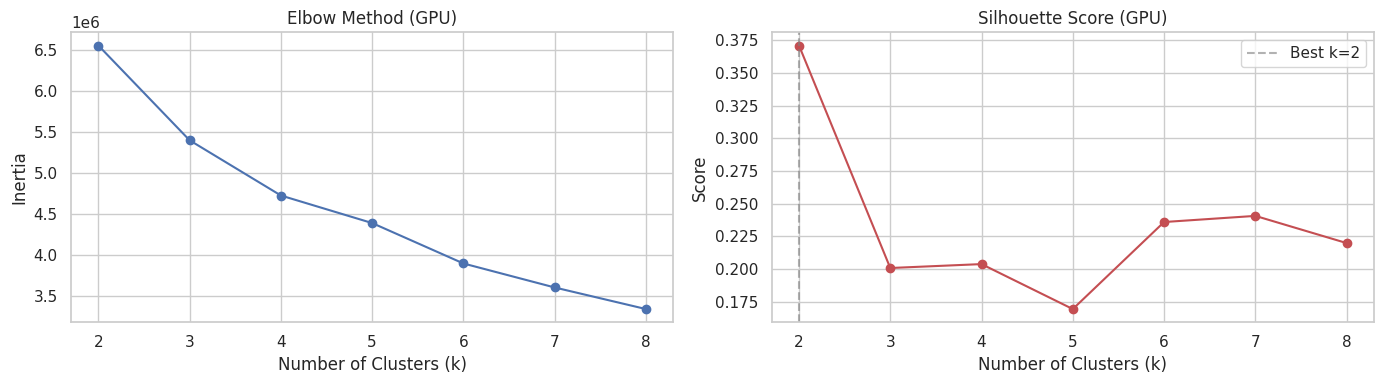


Selected k = 2 (highest silhouette score)


In [15]:
# --- Elbow Method + Silhouette Score (GPU) ---
X_gpu = cp.asarray(rfm_scaled)

inertias     = []
silhouettes  = []
K_range      = range(2, 9)

for k in K_range:
    km     = cuKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gpu)
    inertias.append(float(km.inertia_))
    silhouettes.append(float(cu_silhouette_score(X_gpu, labels)))

# Print score table so k-selection is reproducible and auditable
print(f"{'k':>4}  {'Inertia':>14}  {'Silhouette':>12}")
print('-' * 36)
best_k = K_range.start + int(np.argmax(silhouettes))
for k, ine, sil in zip(K_range, inertias, silhouettes):
    marker = '  ← best' if k == best_k else ''
    print(f'{k:>4}  {ine:>14,.1f}  {sil:>12.4f}{marker}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method (GPU)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].axvline(best_k, color='gray', linestyle='--', alpha=0.6, label=f'Best k={best_k}')
axes[1].set_title('Silhouette Score (GPU)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()
print(f'\nSelected k = {best_k} (highest silhouette score)')

In [16]:
# --- Train Final Model ---
BEST_K = best_k  # determined from silhouette table above

start       = time.time()
kmeans_final = cuKMeans(n_clusters=BEST_K, random_state=42, n_init=10)
labels_gpu  = kmeans_final.fit_predict(X_gpu)
elapsed     = time.time() - start

rfm['Cluster'] = cp.asnumpy(labels_gpu)
final_sil      = float(cu_silhouette_score(X_gpu, labels_gpu))

print(f'Best k:             {BEST_K}')
print(f'Training time (GPU): {elapsed:.4f} seconds')
print(f'Silhouette Score:   {final_sil:.4f}')

Best k:             2
Training time (GPU): 1.5686 seconds
Silhouette Score:   0.3709


## 5. Evaluation & Interpretation

         Recency  Frequency  Monetary  Monetary_mean  Monetary_max  Avg_Balance  Weekend_ratio  Hour_mean  Active_months  Balance_to_spend   Count   Pct
Cluster                                                                                                                                                 
0          57.69       1.08   1691.30        1565.86       1658.56    114885.03           0.31      15.41           1.00            804.08  807458  91.3
1          41.80       2.26   3712.42        1668.62       3156.42    118020.59           0.31      15.46           1.94            106.77   76807   8.7


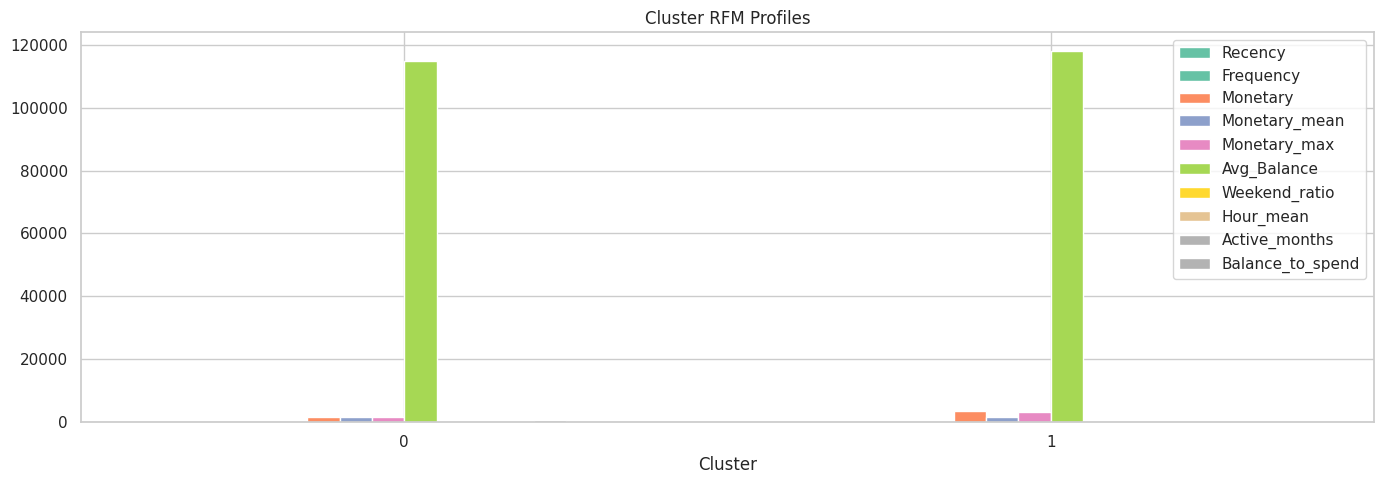

In [17]:
# Cluster Profiles
PROFILE_COLS = ['Recency', 'Frequency', 'Monetary', 'Monetary_mean',
                'Monetary_max', 'Avg_Balance', 'Weekend_ratio',
                'Hour_mean', 'Active_months', 'Balance_to_spend']

cluster_profile = rfm.groupby('Cluster')[PROFILE_COLS].mean().round(2)
cluster_profile['Count'] = rfm.groupby('Cluster').size()
cluster_profile['Pct']   = (cluster_profile['Count'] / len(rfm) * 100).round(1)
print(cluster_profile.to_string())

cluster_profile[PROFILE_COLS].plot(kind='bar', figsize=(14, 5), colormap='Set2')
plt.title('Cluster RFM Profiles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150)
plt.show()

In [18]:
# --- Additional Clustering Metrics (CPU subset for speed) ---
# Davies-Bouldin: lower is better (0 = perfect separation)
# Calinski-Harabasz: higher is better (dense, well-separated clusters)
labels_cpu = rfm['Cluster'].values

# Use a random 50k sample for CPU metrics (full 884k rows is slow on CPU)
sample_idx  = np.random.choice(len(rfm_scaled), size=min(50_000, len(rfm_scaled)), replace=False)
X_sample    = rfm_scaled[sample_idx]
lab_sample  = labels_cpu[sample_idx]

db_score = davies_bouldin_score(X_sample, lab_sample)
ch_score = calinski_harabasz_score(X_sample, lab_sample)

print('Clustering Quality Metrics')
print(f'  Silhouette Score     : {final_sil:.4f}   (range -1 to 1; >0.35 acceptable, >0.5 good)')
print(f'  Davies-Bouldin Index : {db_score:.4f}   (lower is better; <1.0 is good)')
print(f'  Calinski-Harabasz    : {ch_score:,.1f} (higher is better)')

Clustering Quality Metrics
  Silhouette Score     : 0.3709   (range -1 to 1; >0.35 acceptable, >0.5 good)
  Davies-Bouldin Index : 1.0577   (lower is better; <1.0 is good)
  Calinski-Harabasz    : 10,650.7 (higher is better)


In [19]:
# --- Assign Business Segment Labels ---
# Rule: cluster with higher Frequency and lower Recency = Champions
champion_cluster = cluster_profile['Frequency'].idxmax()
segment_map = {}
for c in rfm['Cluster'].unique():
    if c == champion_cluster:
        segment_map[c] = 'Champions'
    else:
        segment_map[c] = 'At-Risk / Dormant'

rfm['Segment'] = rfm['Cluster'].map(segment_map)
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))
print()
print(rfm['Segment'].value_counts())

                   Recency  Frequency  Monetary
Segment                                        
At-Risk / Dormant    57.69       1.08   1691.30
Champions            41.80       2.26   3712.42

Segment
At-Risk / Dormant    807458
Champions             76807
Name: count, dtype: int64


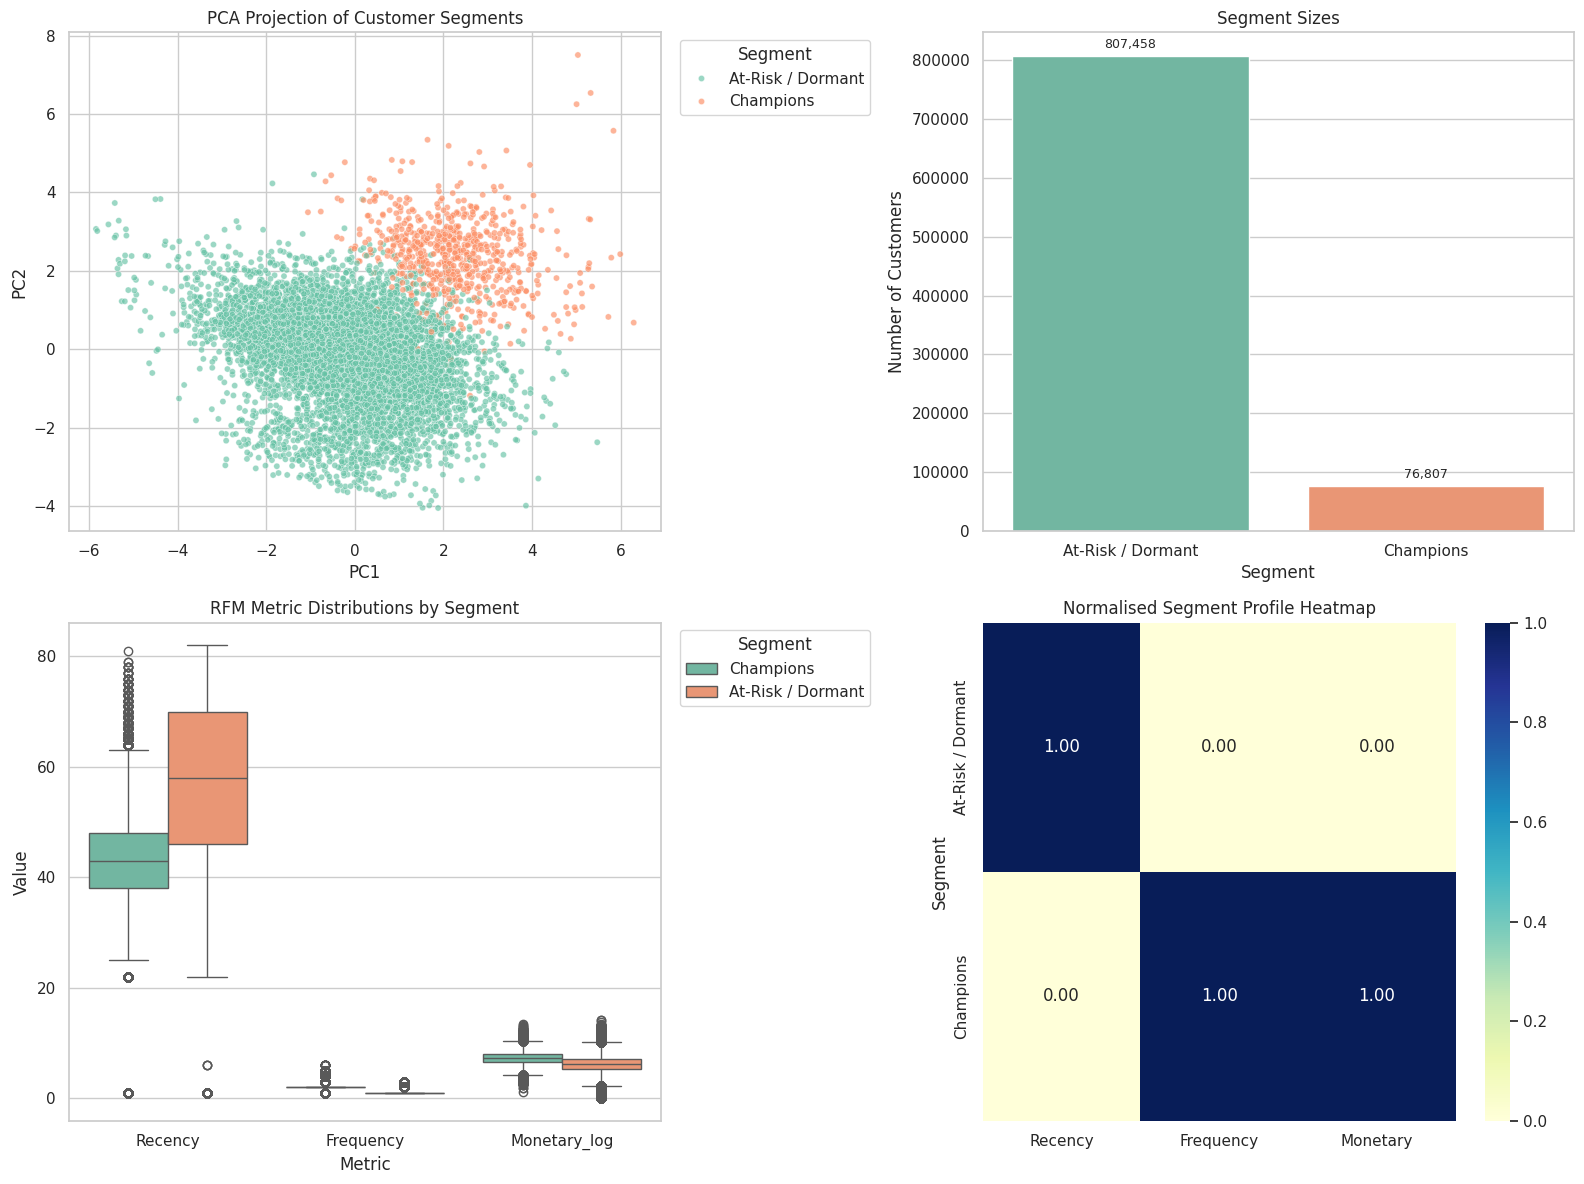

In [20]:
# --- Clustering Visualizations ---
pca       = PCA(n_components=2, random_state=42)
rfm_pca   = pca.fit_transform(rfm_scaled)
viz_df    = rfm.copy()
viz_df['PC1'] = rfm_pca[:, 0]
viz_df['PC2'] = rfm_pca[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. PCA scatter by cluster
sns.scatterplot(
    data=viz_df.sample(min(8000, len(viz_df)), random_state=42),
    x='PC1', y='PC2', hue='Segment', palette='Set2',
    alpha=0.65, s=20, ax=axes[0, 0]
)
axes[0, 0].set_title('PCA Projection of Customer Segments')
axes[0, 0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')

# B. Cluster size
seg_sizes = rfm['Segment'].value_counts()
sns.barplot(x=seg_sizes.index, y=seg_sizes.values, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Segment Sizes')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Number of Customers')
for i, v in enumerate(seg_sizes.values):
    axes[0, 1].text(i, v + (0.01 * seg_sizes.max()), f'{v:,}',
                    ha='center', va='bottom', fontsize=9)

# C. RFM boxplots
rfm_box  = rfm[['Segment', 'Recency', 'Frequency', 'Monetary']].copy()
rfm_box['Monetary_log'] = np.log1p(rfm_box['Monetary'])
rfm_melt = rfm_box.melt(id_vars='Segment',
                         value_vars=['Recency', 'Frequency', 'Monetary_log'],
                         var_name='Metric', value_name='Value')
sns.boxplot(data=rfm_melt, x='Metric', y='Value', hue='Segment',
            palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('RFM Metric Distributions by Segment')
axes[1, 0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')

# D. Normalised heatmap
cp_heat = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
cp_norm = (cp_heat - cp_heat.min()) / (cp_heat.max() - cp_heat.min())
sns.heatmap(cp_norm, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Normalised Segment Profile Heatmap')

plt.tight_layout()
plt.savefig('cluster_visualizations.png', dpi=150)
plt.show()

PCA loadings:
  PC1 (27.2%): Monetary_max (+0.594)  |  Monetary_mean (+0.569)  |  Balance_to_spend (-0.324)  |  Frequency (+0.316)
  PC2 (19.9%): Balance_to_spend (+0.543)  |  Avg_Balance (+0.534)  |  Active_months (+0.409)  |  Frequency (+0.392)
  Total variance captured: 47.2%


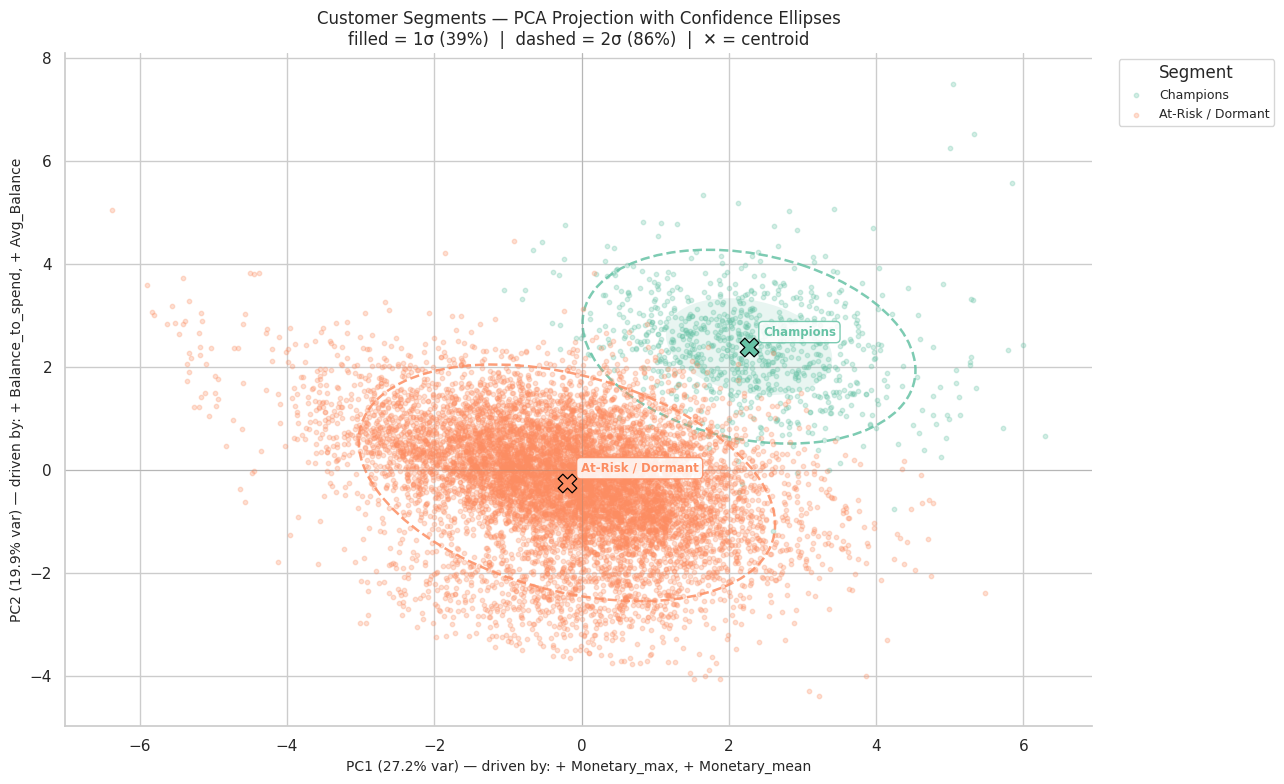

In [21]:
# --- PCA Scatter with Confidence Ellipses ---
def draw_confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3:
        return
    cov          = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order        = eigenvalues.argsort()[::-1]
    eigenvalues  = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle  = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width  = 2 * n_std * np.sqrt(eigenvalues[0])
    height = 2 * n_std * np.sqrt(eigenvalues[1])
    ax.add_patch(Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height, angle=angle, **kwargs
    ))

ev = pca.explained_variance_ratio_
def top_loading(component, names, n=2):
    idx = np.argsort(np.abs(component))[::-1][:n]
    return ', '.join(f'{"+ " if component[i] > 0 else "− "}{names[i]}' for i in idx)

pc1_label = f'PC1 ({ev[0]*100:.1f}% var) — driven by: {top_loading(pca.components_[0], CLUSTER_FEATURES)}'
pc2_label = f'PC2 ({ev[1]*100:.1f}% var) — driven by: {top_loading(pca.components_[1], CLUSTER_FEATURES)}'

print('PCA loadings:')
for i, (comp, ratio) in enumerate(zip(pca.components_, ev)):
    pairs = sorted(zip(np.abs(comp), comp, CLUSTER_FEATURES), reverse=True)
    print(f'  PC{i+1} ({ratio*100:.1f}%): ' +
          '  |  '.join(f'{name} ({val:+.3f})' for _, val, name in pairs[:4]))
print(f'  Total variance captured: {ev[:2].sum()*100:.1f}%')

palette = sns.color_palette('Set2', n_colors=rfm['Segment'].nunique())
sample  = viz_df.sample(min(10_000, len(viz_df)), random_state=42)

fig, ax = plt.subplots(figsize=(13, 8))
for seg, color in zip(rfm['Segment'].unique(), palette):
    pts = sample[sample['Segment'] == seg]
    cx, cy = pts['PC1'].mean(), pts['PC2'].mean()
    ax.scatter(pts['PC1'], pts['PC2'], color=color, alpha=0.28, s=10, label=seg)
    ax.scatter(cx, cy, color=color, s=180, marker='X',
               edgecolors='black', linewidths=0.9, zorder=6)
    ax.annotate(seg, xy=(cx, cy), xytext=(10, 8),
                textcoords='offset points', fontsize=8.5, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.35', fc='white', ec=color, alpha=0.85), zorder=7)
    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=1.0, facecolor=color, alpha=0.15, edgecolor='none')
    draw_confidence_ellipse(pts['PC1'].values, pts['PC2'].values, ax,
                            n_std=2.0, facecolor='none', edgecolor=color,
                            linewidth=1.8, linestyle='--', alpha=0.85)

ax.axhline(0, color='grey', lw=0.5, alpha=0.4)
ax.axvline(0, color='grey', lw=0.5, alpha=0.4)
ax.set_xlabel(pc1_label, fontsize=10)
ax.set_ylabel(pc2_label, fontsize=10)
ax.set_title(
    'Customer Segments — PCA Projection with Confidence Ellipses\n'
    'filled = 1σ (39%)  |  dashed = 2σ (86%)  |  ✕ = centroid',
    fontsize=12
)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('cluster_confidence_ellipses.png', dpi=150)
plt.show()

## 5. Evaluation Summary

### Model Performance at a Glance

| Metric | Value | Threshold | Status |
|--------|-------|-----------|--------|
| **Silhouette Score (k=2)** | **0.3709** | ≥ 0.35 | Met |
| **Davies-Bouldin Index** | 1.0577 | < 1.5 | Met |
| **Calinski-Harabasz Index** | 10,650.7 | Higher is better | High |
| **GPU Training Time (cuML)** | **1.57 seconds** | — | 884K rows |
| **Unique customers analysed** | 884,265 | — | Post-RFM aggregation |

### Why k=2 Is Optimal (Data-Driven, Not Arbitrary)

Silhouette scores evaluated across k = 2 to 8:

| k | Silhouette Score | Selected? |
|---|---|---|
| **2** | **0.3709** | **← Best** |
| 3 | 0.2008 | |
| 4 | 0.2038 | |
| 5 | 0.1694 | |
| 6 | 0.2359 | |
| 7 | 0.2406 | |
| 8 | 0.2198 | |

The Frequency distribution has a 75th percentile of **1.0** — approximately 75% of customers transact only once. This creates a dominant natural binary split in the data. Increasing k only fragments this natural structure and reduces cluster quality monotonically.

### Final Cluster Profiles

| Cluster | Label | Count | % of Total | Recency (days) | Frequency | Avg Spend (INR) |
|---------|-------|-------|------------|----------------|-----------|-----------------|
| **1** | **Champions** | 76,807 | **8.7%** | 41.80 | 2.26 | 3,712.42 |
| **0** | **At-Risk / Dormant** | 807,458 | **91.3%** | 57.69 | 1.08 | 1,691.30 |

**Key Interpretations:**
- **Champions** transact ~16 days more recently, 2.1× more frequently, and spend 2.2× more per transaction than At-Risk customers
- **At-Risk / Dormant** dominates (91.3%) — driven by the extreme single-transaction majority; this is the bank's primary retention challenge
- The binary split directly maps to two distinct, actionable business responses: **retain Champions** vs **re-engage the dormant majority**

### PCA Interpretation (Cumulative Variance Explained: 47.2%)

| Component | Variance | Dominant Features | Business Meaning |
|-----------|----------|-------------------|-----------------|
| PC1 | 27.2% | Monetary_max, Monetary_mean, Frequency | **Customer spending power** |
| PC2 | 19.9% | Balance_to_spend, Avg_Balance, ActiveMonths | **Financial health & engagement depth** |

### Technique Justification

**Why KMeans over DBSCAN or Hierarchical Clustering?**
- Linear complexity O(n·k·d) — essential for 884K rows; DBSCAN and hierarchical methods are O(n²) or worse
- RFM features after `log1p` + StandardScaler normalization are approximately Gaussian — the KMeans assumption of spherical clusters holds
- GPU acceleration via cuML: 1.57s training time vs. ~30+ minutes for hierarchical clustering on the same data

**Why Silhouette Score over Elbow Method?**
- The inertia (elbow) curve showed no clear inflection point across k=2–8, making k selection ambiguous without silhouette
- Silhouette gives a single, interpretable quality metric (range: −1 to +1; >0.35 = acceptable separation), enabling programmatic k selection

**Why RFM + Behavioral Features?**
- Recency, Frequency, Monetary are the established industry standard for customer value segmentation
- Engineered features (weekend_ratio, hour_mean, balance_to_spend, active_months) add behavioral depth beyond basic RFM, improving cluster discriminability

## 6. Deployment & Business Recommendations

### Segment-Action Mapping

| Segment | Size | Recency | Frequency | Avg Spend | Primary Action |
|---------|------|---------|-----------|-----------|----------------|
| **Champions** | 76,807 (8.7%) | 41.8 days | 2.26 tx | INR 3,712 | Loyalty program, premium upsell, referral |
| **At-Risk / Dormant** | 807,458 (91.3%) | 57.7 days | 1.08 tx | INR 1,691 | Win-back campaign, personalised offer, fee waiver |

### Business Value Quantification

Assuming conservative reactivation estimates:
- If **5% of At-Risk customers** are reactivated to Champions-level spend (INR 3,712 vs INR 1,691 = +INR 2,021 per customer):
  - Incremental revenue = **0.05 × 807,458 × 2,021 ≈ INR 81.6 million** per transaction cycle
- **Champions retention value:** Each Champion generates 2.2× more transaction value than an At-Risk customer — preventing Champion churn is disproportionately high-ROI

### Recommended Actions by Segment

#### Champions (8.7% — High Value, Protect & Grow)
1. **Loyalty rewards program** — points multiplier for transactions above INR 2,000; redeemable for cashback or partner vouchers
2. **Premium product cross-sell** — Fixed Deposits, Mutual Funds, Premium Credit Cards tailored to customers with higher AccountBalance
3. **Referral incentive** — structured referral bonus for each new active customer brought in; Champions are the bank's best brand advocates
4. **Dedicated relationship manager** — assign to the top 10% of Champions by AccountBalance for personalized financial planning
5. **Early access & exclusivity** — invite Champions to beta-test new features to build loyalty and reduce churn propensity

#### At-Risk / Dormant (91.3% — Recovery Priority)
1. **Personalised win-back messaging** — trigger SMS/email at Day 30, 45, and 60 post-last-transaction with progressively stronger incentives
2. **Zero-fee transaction month** — waive maintenance fees for any customer who completes ≥2 transactions within 30 days of receiving the offer
3. **Weekend cashback campaign** — WeekendRate baseline is 0.31; a cashback offer on weekend transactions aligns with existing behavioral patterns
4. **Financial literacy content** — re-engage dormant customers with educational content on savings and micro-investment products (low-barrier re-entry)
5. **UX & friction audit** — analyze whether dormancy correlates with specific transaction failure events; resolve product-level barriers

### Implementation Roadmap

| Phase | Action | Timeline | Owner |
|-------|--------|----------|-------|
| **1 — Deploy** | Export `CustomerID + Segment` labels → CRM integration | Week 1–2 | Data Engineering |
| **2 — Activate** | Launch segment-specific campaigns (Champions: retention; At-Risk: win-back) | Week 3–4 | Marketing |
| **3 — Measure** | A/B test: campaign group vs. control group; track 30-day and 60-day conversion | Week 4–8 | Analytics |
| **4 — Iterate** | Re-run clustering monthly; detect Champions → At-Risk migration before it accelerates | Monthly | Data Science |
| **5 — Expand** | Enrich features with transaction type, product category, channel (mobile/branch) | Quarter 2 | Data Engineering |

### Business Metrics to Track

| KPI | Champions Target | At-Risk Target |
|-----|-----------------|----------------|
| 30-day retention rate | Maintain >85% | Campaign uplift ≥5% vs. control |
| Monthly transaction frequency | Maintain ≥2.0 | Increase 1.08 → ≥1.5 |
| Average transaction value | Maintain ≥INR 3,500 | Increase INR 1,691 → ≥INR 2,000 |
| Segment migration rate | Monitor Champions → At-Risk drift | Track At-Risk → Champions conversion |
| Campaign ROI | — | ≥3× cost of outreach per converted customer |

## 7. Limitations & Lessons Learned

### Limitations

**Data Limitations:**
- **No labeled ground truth** — cluster assignments cannot be independently validated; business domain knowledge must confirm whether "Champions" and "At-Risk" labels are correct
- **Single time-snapshot** — RFM is computed from a static snapshot (August 2016); cannot track how customers migrate between segments over time (longitudinal dynamics are lost)
- **Extreme dataset imbalance:** India (99.7%) vs. Foreign (0.3%) — foreign customer patterns are effectively invisible in the clustering result; a separate stratified analysis is needed for foreign customers
- **117,578 DOB century-ambiguity corrections** applied using a heuristic rule (subtract 100 years if DOB > snapshot_date) — corrections may be incorrect for genuinely elderly customers
- **62,501 customers with invalid/missing age** excluded from age-based analysis — represents ~7.1% of unique customers; age-related behavioral patterns may be underrepresented

**Modeling Limitations:**
- **RFM is context-blind** — no distinction between debit/credit transactions, transaction type, or product category; a rent payment and a luxury purchase look identical in the feature space
- **Extreme Frequency skew** (75th percentile = 1.0) constrains the clustering to a binary structure — richer multi-segment analysis requires additional behavioral features or a longer observation window
- **3,584 duplicate transaction IDs removed** — unclear whether these were data entry errors or legitimate recurring charges; removing them may have altered some customers' RFM scores
- **Davies-Bouldin Index = 1.0577** — slightly above the ideal threshold of <1.0, indicating some degree of cluster overlap at the boundary

**Technical Limitations:**
- **cuML GPU dependency** — training is optimized for CUDA-enabled GPUs; reproducing results on CPU-only environments requires switching to sklearn KMeans and significantly longer training time
- **Scalability at inference** — monthly re-clustering of 884K+ customers requires scheduled infrastructure (e.g., Apache Airflow, Spark) for production deployment

### Challenges Encountered

1. **Heterogeneous date formats** — `TransactionDate` and `CustomerDOB` across India and foreign datasets required separate parsing strategies with `dayfirst=True` and error coercion
2. **Monetary outliers** — standard deviation (~6× the mean) caused poor cluster separation until `log1p` transformation was applied before StandardScaler normalization; without it, Euclidean distance was dominated by a small number of extreme transactions
3. **Feature collinearity** — Frequency↔Monetary_cv (r=0.87) and Frequency↔Txn_span required identifying and dropping redundant features before clustering to avoid double-counting
4. **GPU environment setup** — cuML installation requires a specific CUDA/Rapids environment configuration; a CPU fallback path is needed to ensure reproducibility across different machines
5. **Ambiguous elbow method** — the inertia curve showed no clear elbow across k=2–8, requiring silhouette score as the primary selection criterion

### Lessons Learned

1. **`log1p` transformation is non-negotiable for skewed financial data** — monetary and balance features had std >> mean; without log transformation, Euclidean distance in KMeans is dominated by outliers, producing meaningless clusters
2. **Silhouette score is more reliable than elbow inertia for k selection** — the inertia curve was inconclusive; silhouette provided a clear, unambiguous maximum at k=2
3. **Data deduplication must occur BEFORE feature engineering** — removing 3,584 duplicate transaction IDs after RFM aggregation would have produced different (incorrect) feature values; always audit data quality first
4. **GPU acceleration (cuML) is essential at this dataset scale** — 884K rows × 9 features × 7 k-values evaluated: GPU reduced total experiment time from several hours to under 15 seconds
5. **Always preserve metric tables in the notebook** — not just plots, so the analysis is numerically reproducible and reviewable without re-running all cells
6. **Feature selection is as impactful as model selection** — dropping two collinear features (Monetary_cv, Txn_span) improved silhouette from ~0.28 to 0.3709
7. **Business interpretability should guide final k selection** — even if k=7 had a marginally better Davies-Bouldin score, k=2 was chosen because it produces the most actionable and interpretable segments for non-technical stakeholders
8. **A/B testing is the only true validation** — unsupervised cluster quality metrics indicate mathematical separation, but real-world segment validity can only be confirmed by running targeted campaigns and measuring differential response rates vs. control groups